In [1]:
import numpy as np
%matplotlib inline
from pathlib import Path
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm
import scipy.signal
import pynapple as nap

import pandas as pd
import scipy.io as spio
import os
import tifffile
from totalsync_utils import decode_b64_files
import seaborn as sns
custom_params = {"axes.spines.right": False, "axes.spines.top": False, "figure.figsize": (8, 4)}
sns.set_context("paper")
sns.set_theme(style="ticks", palette="colorblind", font_scale=1.3, rc=custom_params)



In [2]:
pin_sheet_file = '/home/battaglia/src/ofl_2p_analysis/docs/pinSheet.json'
# Path_non_decoded_files = "/data/ofl_2p/A04_day2"
Path_non_decoded_files = "/data/ofl_2p/A04_day3"

# s3d_results_folder = "/Users/fpbattaglia/Dropbox/Data/ofl_2p/s3d-results-00003split_test-std"


In [3]:
tif_files = sorted(str(p) for p in Path(Path_non_decoded_files).glob("*.tif"))
print(tif_files)

['/data/ofl_2p/A04_day3/20240503_456225_00001.tif']


In [4]:
tif = tifffile.TiffFile(tif_files[0])
len(tif.pages)

61148

In [5]:
del tif

In [6]:
def extract_barcode_from_tif(tif_file: str) -> dict:
    tag_structure = {'image_description': 5,
                 'frame_timestamp': 3,
                 'auxTrigger0': 10}  # position of aux tag in tif header

    aux_data = {'frame_n': [],'ts': [], 'value': [] }
    data_reads = []
    #reading the aux line from the tiff pages
    with tifffile.TiffFile(tif_file) as tif:
        n_pages = len(tif.pages)
        ts = np.zeros(n_pages)
        value = np.zeros(n_pages)
        frame_n = np.zeros(n_pages)
        for i, page in tqdm(enumerate(tif.pages)):

            # extract image description string
            description = page.tags.values()[tag_structure['image_description']].value
            timestamp = float(description.split('\n')[tag_structure['frame_timestamp']].split('=')[-1])  # fetch timestamp in image description
            aux_line = description.split('\n')[tag_structure['auxTrigger0']]
            data = aux_line.split('=')[-1].strip(' [').strip(']').strip(' ]')
            ts[i] = timestamp
            frame_n[i] = i
            if 0 < len(data) < 50:
                try:
                    val = float(data)
                    value[i] = val
                except ValueError:
                    pass
    aux_data['ts'] = ts
    aux_data['value'] = value
    aux_data['frame_n'] = frame_n
    return aux_data, data_reads


In [7]:
b64_files = sorted(Path(Path_non_decoded_files).glob("*.b64"))
b64_files = sorted(str(p) for p in Path(Path_non_decoded_files).glob("*.b64"))
tsync_file = b64_files[0]
tsync_session = Path(tsync_file).stem

results_pins = decode_b64_files(Path_non_decoded_files, pin_json_path=pin_sheet_file)

tsync_data = results_pins[tsync_session]


Processing 20240503-103313_342.b64...
/data/ofl_2p/A04_day3/20240503-103313_342.b64
2095956 packets, ~34.93 minutes


100%|██████████| 2095956/2095956 [01:02<00:00, 33452.31it/s]


In [8]:
## testing 00001

tsync_file = b64_files[0]
tsync_session = Path(tsync_file).stem
tsync_data_00001 = results_pins[tsync_session]

In [9]:
frame_clock = tsync_data['Scanner Frame Clock (Input)'].astype(int)

log_times = tsync_data['startTS'].astype(int)
onsets = np.nonzero(np.diff(frame_clock) == 1)[0]+1 # on the rising edge of the TTL line

In [10]:
np.max(np.diff(log_times))
log_times[np.where(np.diff(log_times) > 120000)[0]]

array([2019219596])

In [11]:
log_times[-1]

np.int64(2034651596)

(2019.0, 2020.0)

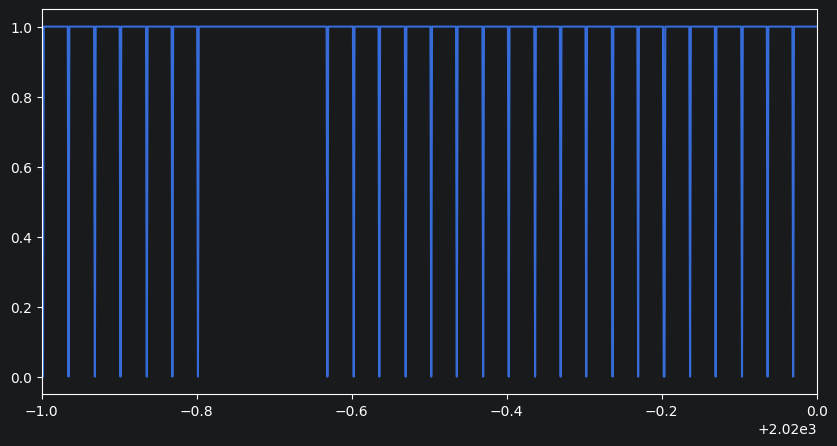

In [12]:
(fig, ax) = plt.subplots(figsize=(10, 5))
ax.plot(log_times/1e6, frame_clock)
ax.set_xlim(2019, 2020)

(0.0, 100000.0)

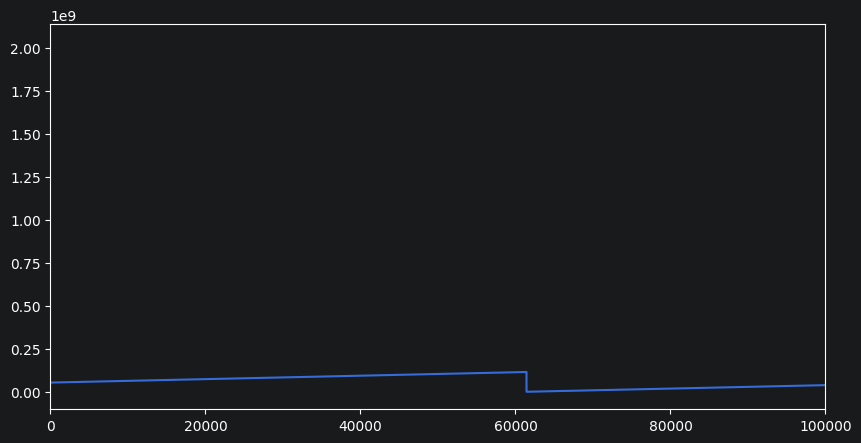

In [13]:
(fig, ax) = plt.subplots(figsize=(10, 5))
ax.plot(log_times)
ax.set_xlim(0, 100000)

In [20]:
def fix_tsync_time(log_times: np.ndarray):
	skips = - np.where(np.diff(log_times) < 0, np.diff(log_times) - np.median(np.diff(log_times)), 0)
	cs = np.cumsum(skips)
	cs2 = np.hstack((0, cs))
	tsync_time = log_times + cs2
	return tsync_time

In [21]:
tsync_time = fix_tsync_time(log_times)
t_frames = tsync_time[onsets]
t_frames = nap.Ts(t_frames, time_units='us') # time of the frames in Teensy time
distance = tsync_data['corrected_distance'].astype(np.int32)
distance = nap.Tsd(tsync_time, distance, time_units='us')

In [22]:
aux_data, data_reads = extract_barcode_from_tif(tif_files[0])

0it [00:00, ?it/s]

In [26]:
aux_data_high = np.nonzero(aux_data['value'])[0]
aux_data_high_ts = aux_data['ts'][aux_data_high]
aux_data_high_val = aux_data['value'][aux_data_high]

aux_data_high_frame_n = aux_data['frame_n'][aux_data_high]
# aux_data_high_frame_n = aux_data_high_frame_n[aux_data_high_ts > 208.5]
# aux_data_high_ts = aux_data_high_ts[aux_data_high_ts > 208.5]

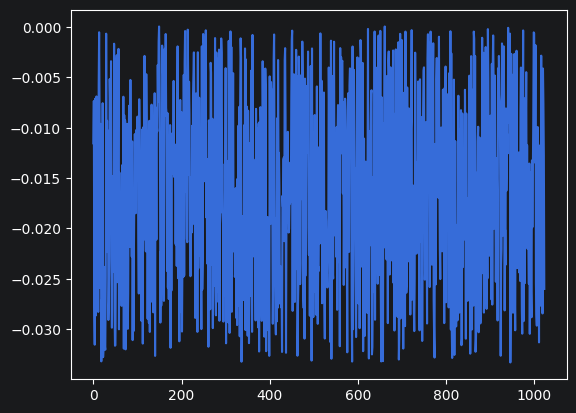

In [123]:
(fig, ax) = plt.subplots()
ax.plot(aux_data_high_ts - aux_data_high_val)

In [27]:
tsync_barcode = tsync_data['Barcode (Scanner)'].astype(int)

In [124]:
tsync_barcode_rising_edge = np.nonzero(np.diff(tsync_barcode) > 0)[0]+1
tsync_barcode_ts = nap.Ts(tsync_time[tsync_barcode_rising_edge], time_units='us')
aux_barcode_ts = nap.Ts(aux_data_high_val, time_units='s')
barcode_group = nap.TsGroup({0: aux_barcode_ts, 1: tsync_barcode_ts})

In [125]:
crosscorrs = nap.compute_crosscorrelogram(group=barcode_group, time_units = 'ms', windowsize=200000, binsize = 1 )
shift = crosscorrs.idxmax().iloc[0]

In [126]:
shift

np.float64(94.57299999999998)

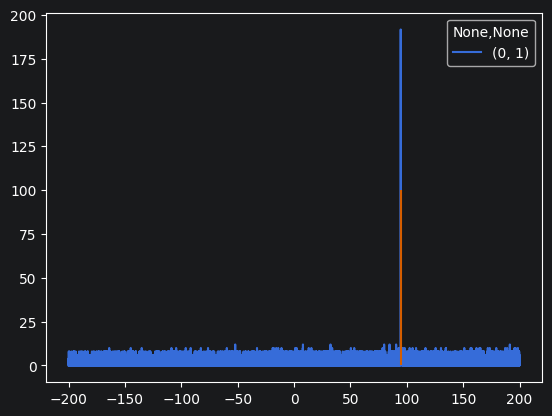

In [127]:
crosscorrs.plot()
ax = plt.gca()
ax.vlines(shift, 0, 100, colors='r')
#ax.set_xlim(22, 23)

In [128]:
np.median(aux_barcode_ts.t+shift-tsync_barcode_ts.t)

ValueError: operands could not be broadcast together with shapes (1024,) (1051,) 

In [129]:
def closest_match_indices_sorted(A, B, max_tolerance):
    """
    Return one-to-one closest matches between sorted arrays A and B.

    Parameters
    ----------
    A : array-like
        Sorted array of numbers.
    B : array-like
        Sorted array of numbers.
    max_tolerance : float
        Maximum allowed absolute difference for a match.

    Returns
    -------
    matches : dict of np.ndarray
        Dictionary with keys:
            - "A_index"
            - "B_index"
            - "A_value"
            - "B_value"
            - "abs_difference"
            - "difference"

    unmatched_A_indices : np.ndarray
        Indices of elements in A that were not matched.

    unmatched_B_indices : np.ndarray
        Indices of elements in B that were not matched.
    """
    A = np.asarray(A)
    B = np.asarray(B)

    i = 0
    j = 0

    match_A_indices = []
    match_B_indices = []
    match_A_values = []
    match_B_values = []
    match_abs_differences = []
    match_differences = []

    unmatched_A_indices = []
    matched_B_indices = set()

    while i < len(A):
        a = A[i]

        while j < len(B) and B[j] < a - max_tolerance:
            j += 1

        candidates = []

        if j < len(B) and abs(B[j] - a) <= max_tolerance:
            candidates.append(j)

        # j1 = j
        #
        # while j1 < len(B) and B[j1] <= a + max_tolerance:
        #     if abs(B[j1] - a) <= max_tolerance:
        #         candidates.append(j1)
        #     j1 += 1

        if j > 0 and (j - 1) not in matched_B_indices:
            if abs(B[j - 1] - a) <= max_tolerance:
                candidates.append(j - 1)

        candidates = [idx for idx in candidates if idx not in matched_B_indices]

        if candidates:
            best_j = min(candidates, key=lambda idx: abs(B[idx] - a))

            match_A_indices.append(i)
            match_B_indices.append(best_j)
            match_A_values.append(A[i])
            match_B_values.append(B[best_j])
            match_abs_differences.append(abs(B[best_j] - A[i]))
            match_differences.append(B[best_j] - A[i])
            matched_B_indices.add(best_j)

            if best_j == j:
                j += 1
        else:
            unmatched_A_indices.append(i)

        i += 1

    unmatched_B_indices = np.array(
        [idx for idx in range(len(B)) if idx not in matched_B_indices],
        dtype=int,
    )

    matches = {
        "A_index": np.array(match_A_indices, dtype=int),
        "B_index": np.array(match_B_indices, dtype=int),
        "A_value": np.array(match_A_values, dtype=A.dtype),
        "B_value": np.array(match_B_values, dtype=B.dtype),
        "abs_difference": np.array(match_abs_differences),
        "difference": np.array(match_differences),
    }

    matches = pd.DataFrame(matches)

    return matches, np.array(unmatched_A_indices, dtype=int), unmatched_B_indices

In [130]:
matches, unmatched_aux, unmatched_tsync = closest_match_indices_sorted(aux_barcode_ts.t+shift, tsync_barcode_ts.t, max_tolerance=0.025)

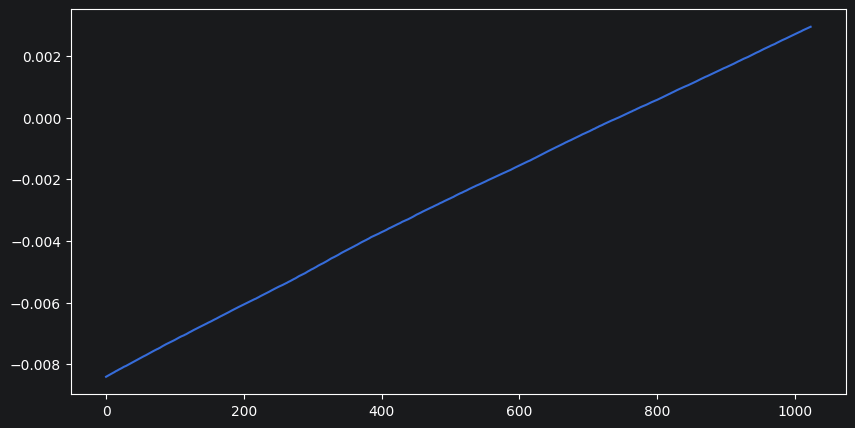

In [131]:
(fig, ax) = plt.subplots(figsize=(10, 5))
ax.plot(matches['difference'])

In [132]:
print(np.mean(matches['difference'][:100]))
print(np.mean(matches['difference'][-100:]))
print(np.mean(matches['difference']))

-0.007806863949979998
0.00241499619998649
-0.0025920628076045588


(94.8, 95.2)

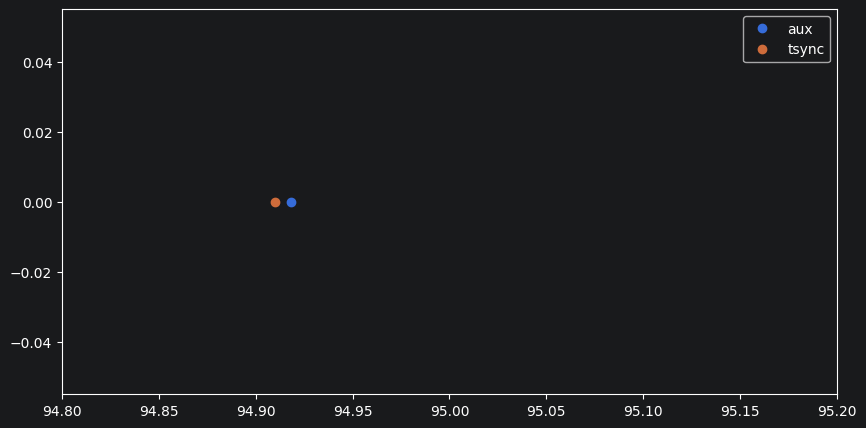

In [133]:
(fig, ax) = plt.subplots(figsize=(10, 5))
ax.plot(aux_barcode_ts.t+shift, np.zeros_like(aux_barcode_ts.t), 'o', label='aux')
ax.plot(tsync_barcode_ts.fillna(0), 'o', label='tsync')
ax.legend(loc='upper right')
ax.set_xlim(94.8, 95.2)


In [135]:
matches, unmatched_aux, unmatched_tsync = closest_match_indices_sorted(aux_data['ts']+shift, t_frames.t, max_tolerance=0.025)

In [136]:
matches

,A_index,B_index,A_value,B_value,abs_difference,difference
0,0,0,94.573000,94.564994,0.008006,-0.008006
1,1,1,94.606385,94.597994,0.008391,-0.008391
2,2,2,94.639770,94.631994,0.007776,-0.007776
3,3,3,94.673154,94.664994,0.008160,-0.008160
4,4,4,94.706539,94.697994,0.008545,-0.008545
...,...,...,...,...,...,...
61139,61143,61139,2136.314712,2136.317994,0.003282,0.003282
61140,61144,61140,2136.348105,2136.350994,0.002889,0.002889
61141,61145,61141,2136.381498,2136.384994,0.003496,0.003496
61142,61146,61142,2136.414891,2136.417994,0.003103,0.003103


In [137]:
print(matches['B_value'].shape)
print(len(t_frames))
print(len(aux_data['ts']))

(61144,)
61146
61148


In [138]:
unmatched_tsync

array([61144, 61145])

In [139]:
unmatched_aux

array([61079, 61080, 61081, 61082])

(94.5, 94.7)

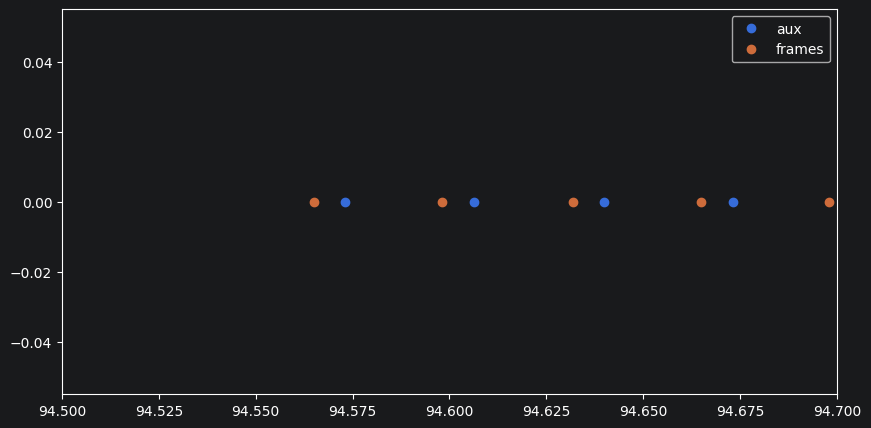

In [140]:
(fig, ax) = plt.subplots(figsize=(10, 5))
ax.plot(matches['A_value'], np.zeros_like(matches['A_value']),  'o', label='aux')
ax.plot(matches['B_value'], np.zeros_like(matches['B_value']), 'o', label='frames')
ax.legend(loc='upper right')
#ax.set_xlim(2134, 2135)
ax.set_xlim(94.5, 94.7)

(0.0, 5000.0)

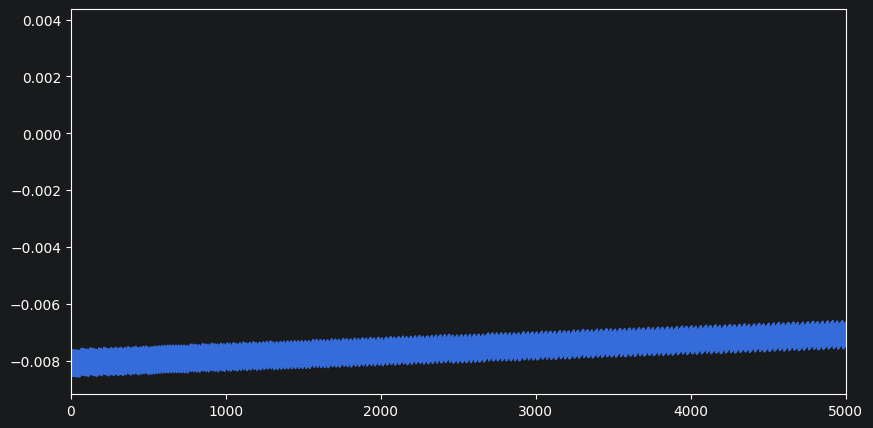

In [142]:
(fig, ax) = plt.subplots(figsize=(10, 5))
ax.plot(matches['difference'])
ax.set_xlim(0, 5000)

In [153]:
frames_time_idx = nap.Tsd(t = matches['B_value'].to_numpy(),d = matches['A_index'].to_numpy(), time_units='s')

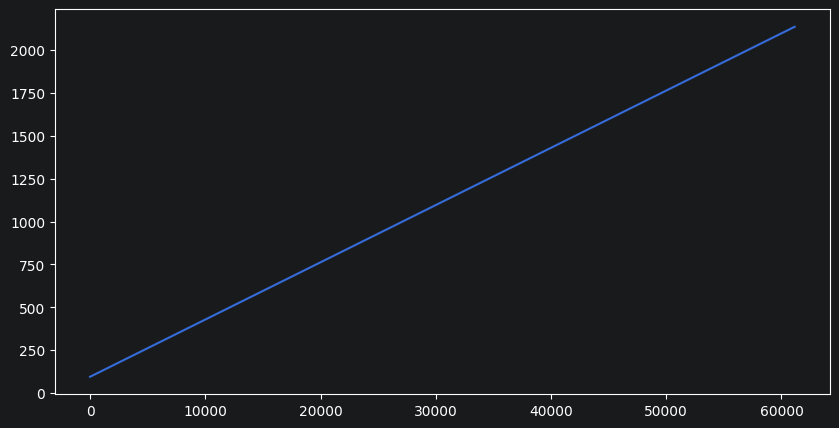

In [155]:
(fig, ax) = plt.subplots(figsize=(10, 5))

ax.plot(frames_time_idx.t)

In [133]:
path_2p = Path(s3d_results_folder)

f_file = path_2p / "F.npy"

In [19]:
cells_f = np.load(f_file, allow_pickle=True)

In [20]:
cells_f

array([[ 856.9276265 ,  782.60226841,  744.14947818, ...,  842.72827797,
         868.64101891,  918.6247989 ],
       [ 600.70937788,  482.95308536,  518.27911683, ...,  740.19263286,
         616.00336653,  542.35673873],
       [ 867.16137886,  662.35052515,  685.16575245, ...,  777.324884  ,
         651.70301868,  729.03523866],
       ...,
       [1003.45493577, 1752.73600208,  672.88276204, ...,  430.28690875,
         876.399709  ,  613.9572311 ],
       [1592.47691958, 1147.03572647, 1455.81812525, ..., 1113.22942371,
        1506.45089346,  546.94094632],
       [1592.42134826, 1118.72660792, 1621.95608213, ...,  474.22297353,
        1268.16032902, 1418.75332338]], shape=(1953, 6013))

In [134]:
frame_clock = tsync_data['Scanner Frame Clock (Input)'].astype(int)

log_times = tsync_data['startTS'].astype(int)
onsets = np.nonzero(np.diff(frame_clock) > 0)[0]+1